# 01 - Segmentação / Isolamento do Objeto

**Cenário A — Inspeção de frutas (maçãs frescas vs podres)**

Objetivo: isolar a fruta do fundo (branco/controlado), gerando uma
**máscara binária** que será usada no notebook 02 para extrair
features apenas da região do objeto.

Vamos comparar **dois métodos de segmentação**:

1. **Limiarização (Threshold/Otsu)** sobre o canal de saturação (HSV)
2. **Watershed** (segmentação baseada em marcadores), útil quando há
   sobreposição ou ruído de fundo mais complexo


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_DIR = "../dataset"
CLASSES = ["fresh", "rotten"]

# lista todos os arquivos de imagem
paths = []
labels = []
for cls in CLASSES:
    files = sorted(glob.glob(os.path.join(DATASET_DIR, cls, "*.png")))
    paths += files
    labels += [cls] * len(files)

print(f"Total de imagens: {len(paths)}")
for cls in CLASSES:
    print(f"  {cls}: {labels.count(cls)}")

Total de imagens: 600
  fresh: 300
  rotten: 300


## Método 1: Threshold (Otsu) no canal de Saturação (HSV)

Frutas costumam ter saturação de cor bem maior que o fundo branco/neutro. Aplicamos Otsu no canal S do HSV e depois operações morfológicas para limpar a máscara.

In [2]:
def segmentar_otsu_saturacao(img_bgr):
    """Segmentação por threshold (Otsu) no canal de saturação (HSV)."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]

    # Otsu
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # limpeza morfológica
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # preencher buracos: pega o maior contorno e desenha preenchido
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        maior = max(contours, key=cv2.contourArea)
        mask_final = np.zeros_like(mask)
        cv2.drawContours(mask_final, [maior], -1, 255, -1)
        return mask_final
    return mask

## Método 2: Watershed (segmentação baseada em marcadores)

Útil para casos com sombras, reflexos fortes ou tocando as bordas. Usamos distância transformada + watershed para separar o objeto do fundo de forma mais robusta a variações de iluminação.

In [3]:
def segmentar_watershed(img_bgr):
    """Segmentação por Watershed usando transformada de distância."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # threshold inicial (Otsu, invertido pq fundo é claro)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # área de fundo certo (dilatação)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # área de objeto certo (erosão / distância)
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # região desconhecida
    unknown = cv2.subtract(sure_bg, sure_fg)

    # marcadores
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(img_bgr.copy(), markers)

    # o objeto principal é o marcador com maior contagem (excluindo fundo=1 e bordas=-1)
    vals, counts = np.unique(markers[markers > 1], return_counts=True)
    if len(vals) == 0:
        return np.zeros(gray.shape, dtype=np.uint8)
    objeto_label = vals[np.argmax(counts)]

    mask = np.uint8(markers == objeto_label) * 255
    return mask

## Comparação visual entre os dois métodos

Vamos aplicar os dois métodos em algumas imagens de exemplo (fresh e rotten) e visualizar lado a lado.

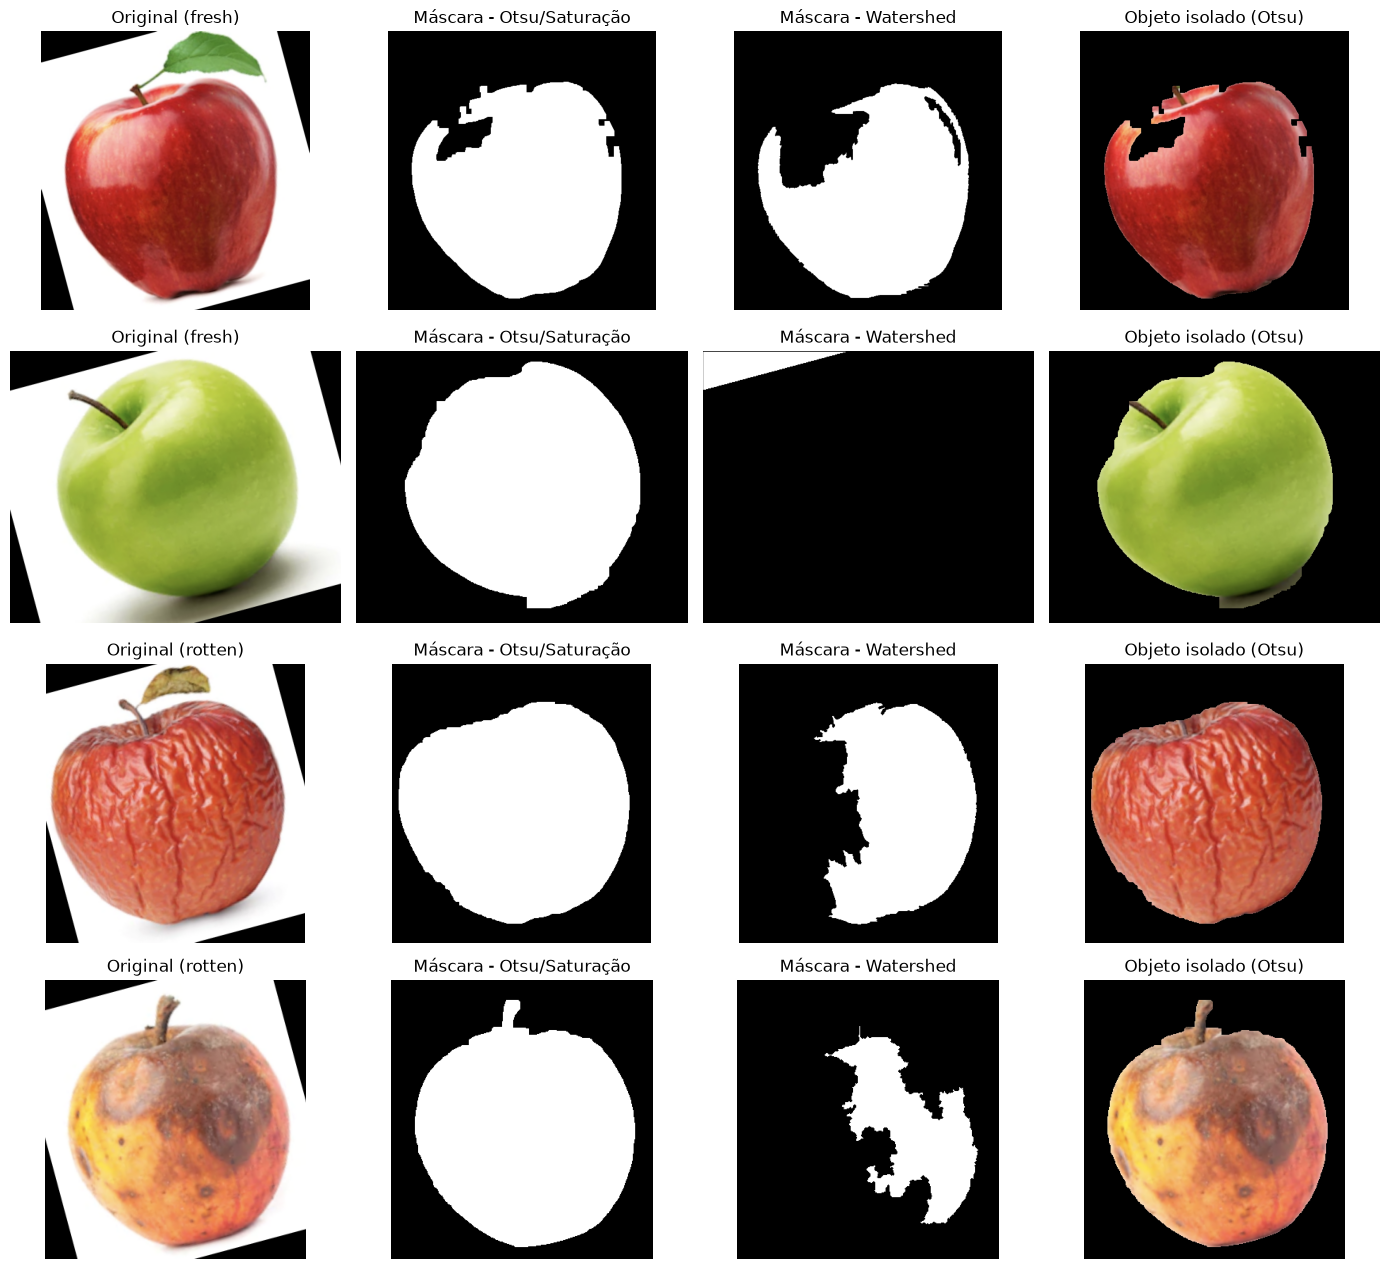

In [4]:
exemplos_idx = [0, 1, len(paths)//2, len(paths)//2 + 1]

fig, axes = plt.subplots(len(exemplos_idx), 4, figsize=(14, 3.2 * len(exemplos_idx)))

for row, idx in enumerate(exemplos_idx):
    img = cv2.imread(paths[idx])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask_otsu = segmentar_otsu_saturacao(img)
    mask_water = segmentar_watershed(img)

    seg_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_otsu)
    seg_water = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_water)

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"Original ({labels[idx]})")
    axes[row, 1].imshow(mask_otsu, cmap="gray")
    axes[row, 1].set_title("Máscara - Otsu/Saturação")
    axes[row, 2].imshow(mask_water, cmap="gray")
    axes[row, 2].set_title("Máscara - Watershed")
    axes[row, 3].imshow(seg_otsu)
    axes[row, 3].set_title("Objeto isolado (Otsu)")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/figuras/comparacao_segmentacao.png", dpi=120, bbox_inches="tight")
plt.show()

## Discussao: acertos e falhas

- **Otsu na saturacao**: funcionou melhor para o dataset real de macas usado neste projeto. A maior parte das imagens tem fundo claro e a fruta possui saturacao maior que o fundo, entao o metodo consegue isolar bem o objeto principal. Em algumas imagens com bordas pretas, reflexos, sombras ou regioes muito claras da fruta, podem aparecer pequenas falhas ou buracos na mascara; por isso aplicamos operacoes morfologicas e preenchimento do maior contorno.

- **Watershed**: foi testado como segundo metodo de segmentacao, mas se mostrou mais sensivel aos parametros e falhou em algumas imagens reais, especialmente quando ha fundo inclinado/preto, sombras fortes ou regioes internas com contraste irregular. Apesar de ser um metodo util em alguns cenarios, neste dataset ele ficou menos estavel que Otsu/Saturacao.

**Escolha para o pipeline**: usamos a mascara do metodo **Otsu na saturacao** como padrao no notebook 02, pois apresentou melhor estabilidade visual e menor complexidade para este dataset real de macas frescas e podres.



In [5]:
# Salva funcao de segmentacao escolhida em um modulo auxiliar para
# reaproveitar no notebook 02 (extracao de features).

codigo = '''
import cv2
import numpy as np


def segmentar(img_bgr):
    """Segmentacao por Otsu no canal de saturacao (HSV).

    Retorna uma mascara binaria (0/255) do objeto principal.
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        maior = max(contours, key=cv2.contourArea)
        mask_final = np.zeros_like(mask)
        cv2.drawContours(mask_final, [maior], -1, 255, -1)
        return mask_final
    return mask
'''

with open("../segmentacao_utils.py", "w", encoding="utf-8") as f:
    f.write(codigo)

print("Modulo segmentacao_utils.py salvo.")


Modulo segmentacao_utils.py salvo.
